In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage.metrics import mean_squared_error, structural_similarity

Результат загрузки изображения:
Размер изображения: (470, 650)


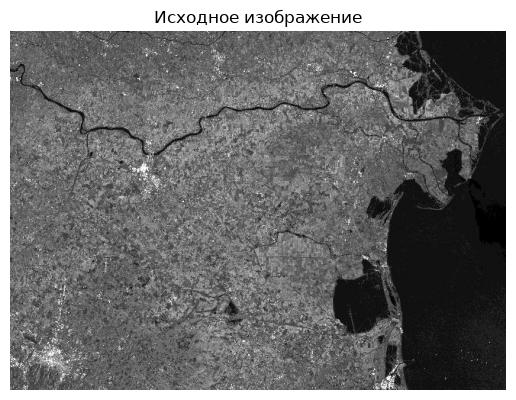

In [2]:
image_gray = cv2.imread('Desktop/sar_my_gray.jpg', cv2.IMREAD_GRAYSCALE)

print('Результат загрузки изображения:')
print('Размер изображения:', image_gray.shape)

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

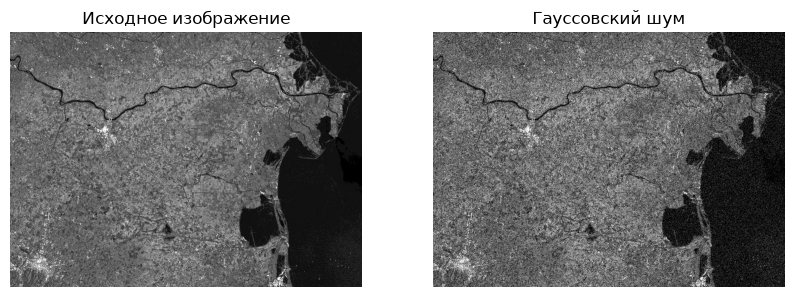

In [3]:
mean = 0
sigma = 25

gaussian_noise = np.random.normal(mean, sigma, image_gray.shape)

gaussian_image = image_gray.astype(np.float32) + gaussian_noise
gaussian_image = np.clip(gaussian_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.show()

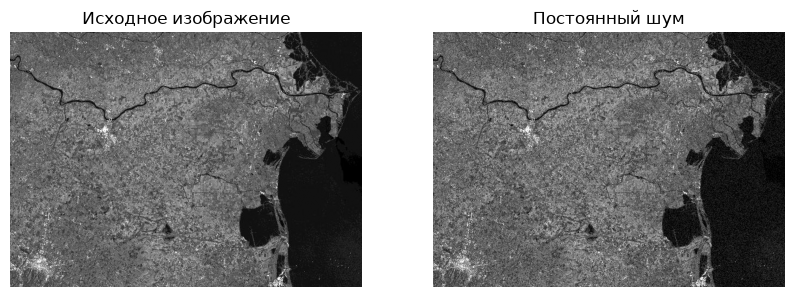

In [27]:
min_noise = -25
max_noise = 25

uniform_noise = np.random.uniform(
    min_noise,
    max_noise,
    image_gray.shape
)

uniform_image = image_gray.astype(np.float32) + uniform_noise
uniform_image = np.clip(uniform_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.show()

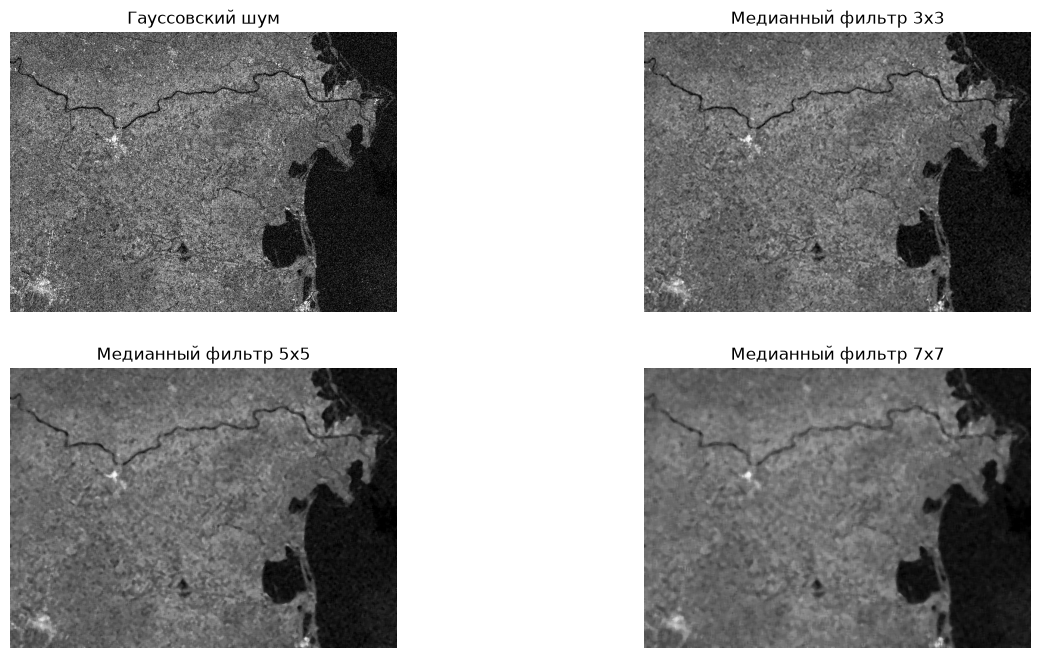

In [7]:
median_3 = cv2.medianBlur(gaussian_image, 3)
median_5 = cv2.medianBlur(gaussian_image, 5)
median_7 = cv2.medianBlur(gaussian_image, 7)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(median_3, cmap='gray')
plt.title('Медианный фильтр 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(median_5, cmap='gray')
plt.title('Медианный фильтр 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_7, cmap='gray')
plt.title('Медианный фильтр 7x7')
plt.axis('off')

plt.show()

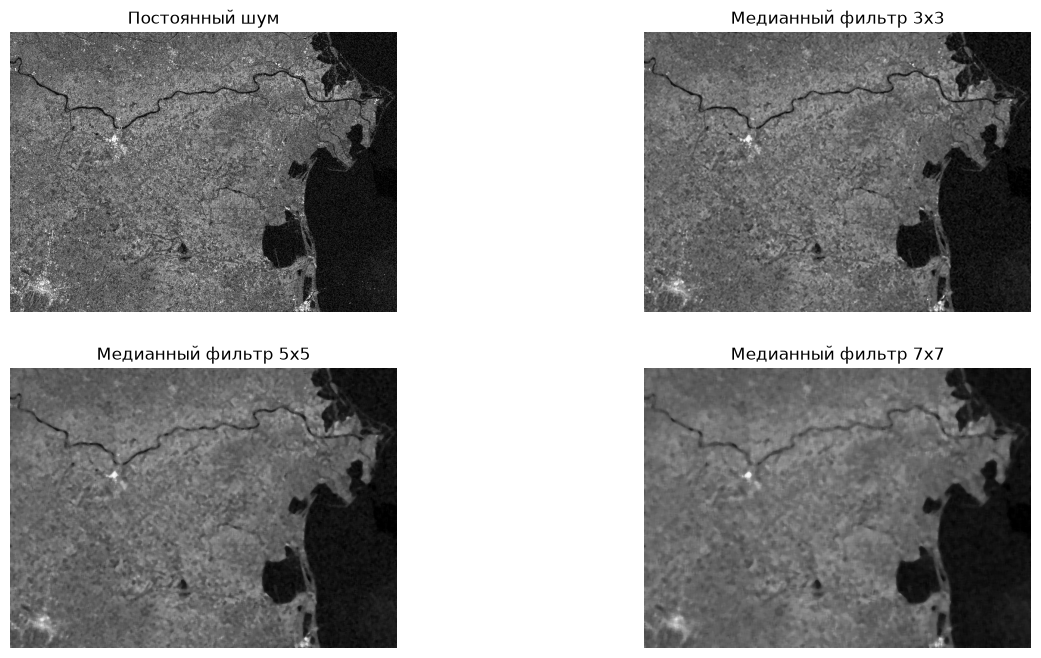

In [29]:
uniform_median_3 = cv2.medianBlur(uniform_image, 3)
uniform_median_5 = cv2.medianBlur(uniform_image, 5)
uniform_median_7 = cv2.medianBlur(uniform_image, 7)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(uniform_median_3, cmap='gray')
plt.title('Медианный фильтр 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(uniform_median_5, cmap='gray')
plt.title('Медианный фильтр 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(uniform_median_7, cmap='gray')
plt.title('Медианный фильтр 7x7')
plt.axis('off')

plt.show()

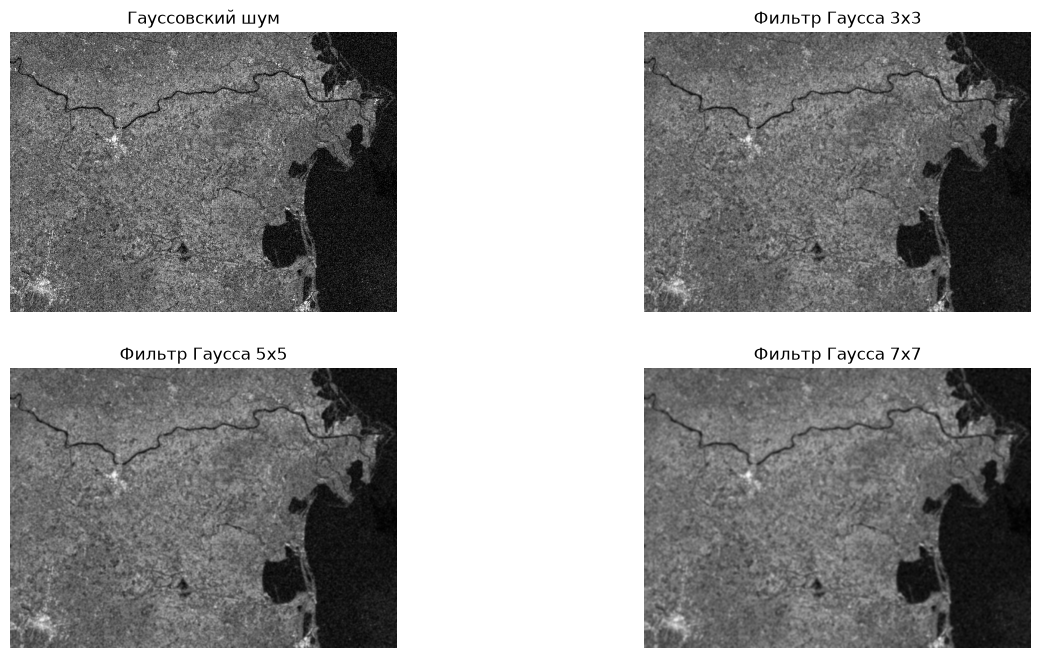

In [9]:
gauss_3 = cv2.GaussianBlur(gaussian_image, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(gaussian_image, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(gaussian_image, (7, 7), 0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gauss_3, cmap='gray')
plt.title('Фильтр Гаусса 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gauss_5, cmap='gray')
plt.title('Фильтр Гаусса 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gauss_7, cmap='gray')
plt.title('Фильтр Гаусса 7x7')
plt.axis('off')

plt.show()

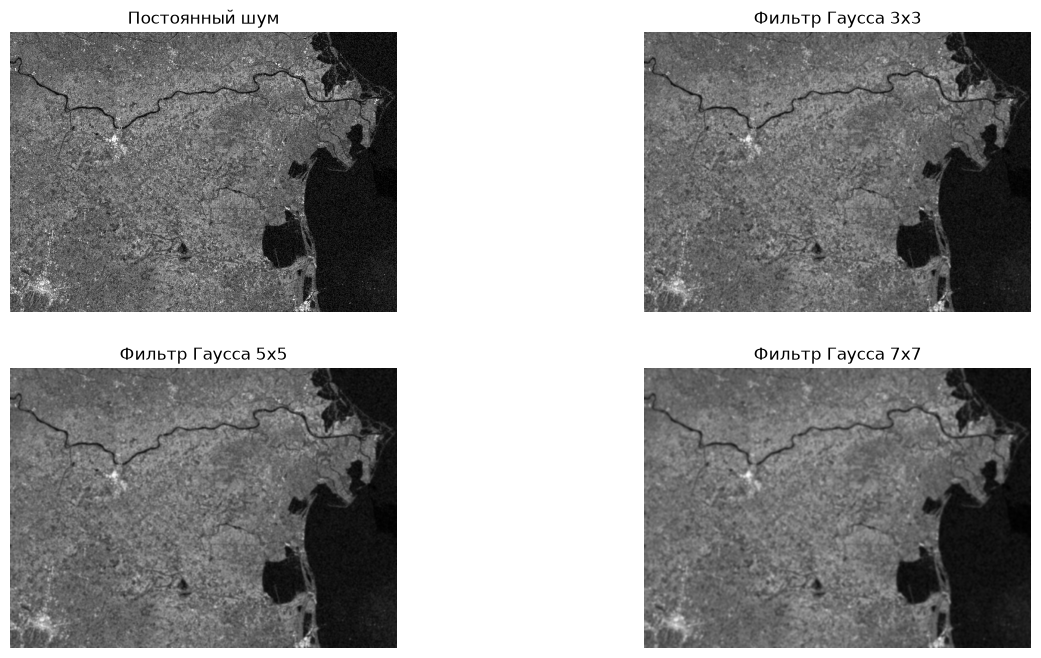

In [30]:
uniform_gauss_3 = cv2.GaussianBlur(uniform_image, (3, 3), 0)
uniform_gauss_5 = cv2.GaussianBlur(uniform_image, (5, 5), 0)
uniform_gauss_7 = cv2.GaussianBlur(uniform_image, (7, 7), 0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(uniform_gauss_3, cmap='gray')
plt.title('Фильтр Гаусса 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(uniform_gauss_5, cmap='gray')
plt.title('Фильтр Гаусса 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(uniform_gauss_7, cmap='gray')
plt.title('Фильтр Гаусса 7x7')
plt.axis('off')

plt.show()

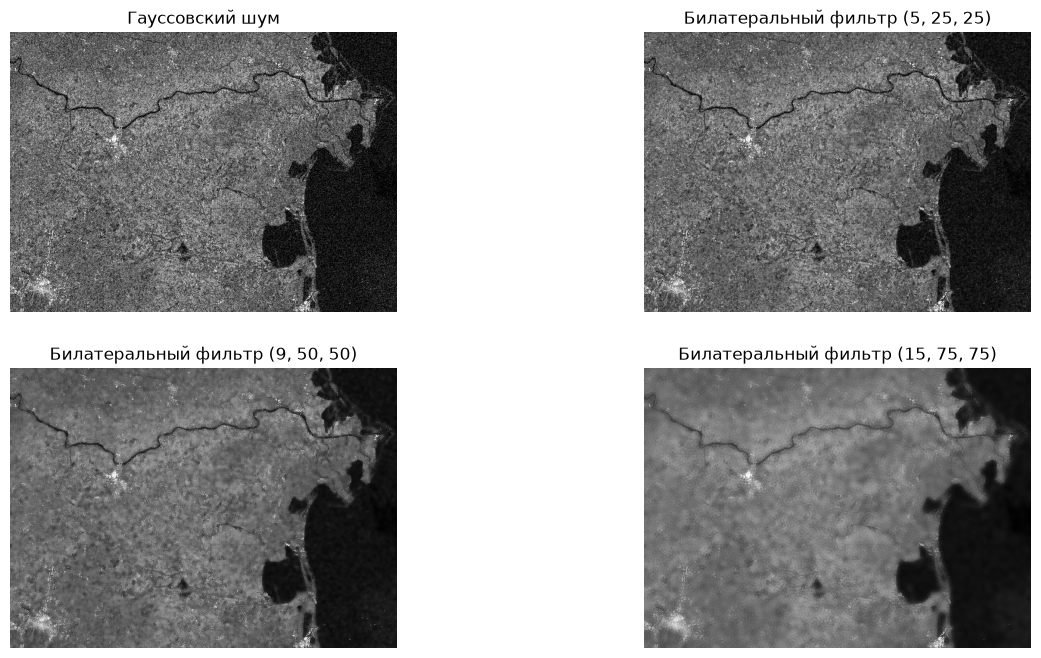

In [14]:
bilateral_1 = cv2.bilateralFilter(gaussian_image, 5, 25, 25)
bilateral_2 = cv2.bilateralFilter(gaussian_image, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(gaussian_image, 15, 75, 75)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bilateral_1, cmap='gray')
plt.title('Билатеральный фильтр (5, 25, 25)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(bilateral_2, cmap='gray')
plt.title('Билатеральный фильтр (9, 50, 50)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral_3, cmap='gray')
plt.title('Билатеральный фильтр (15, 75, 75)')
plt.axis('off')

plt.show()

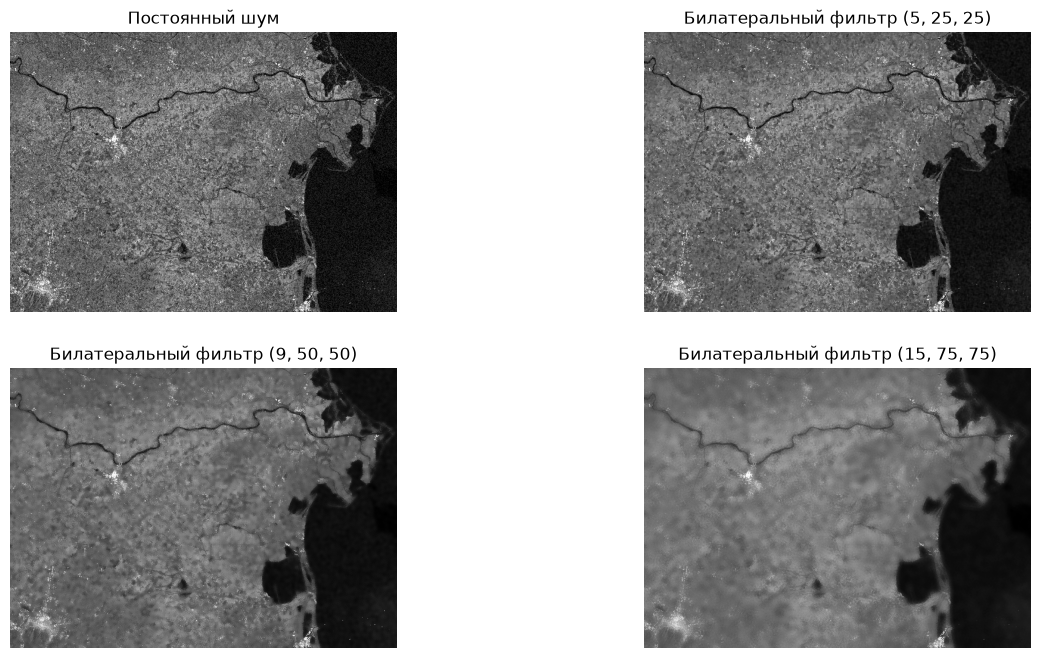

In [31]:
uniform_bilateral_1 = cv2.bilateralFilter(uniform_image, 5, 25, 25)
uniform_bilateral_2 = cv2.bilateralFilter(uniform_image, 9, 50, 50)
uniform_bilateral_3 = cv2.bilateralFilter(uniform_image, 15, 75, 75)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(uniform_bilateral_1, cmap='gray')
plt.title('Билатеральный фильтр (5, 25, 25)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(uniform_bilateral_2, cmap='gray')
plt.title('Билатеральный фильтр (9, 50, 50)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(uniform_bilateral_3, cmap='gray')
plt.title('Билатеральный фильтр (15, 75, 75)')
plt.axis('off')

plt.show()

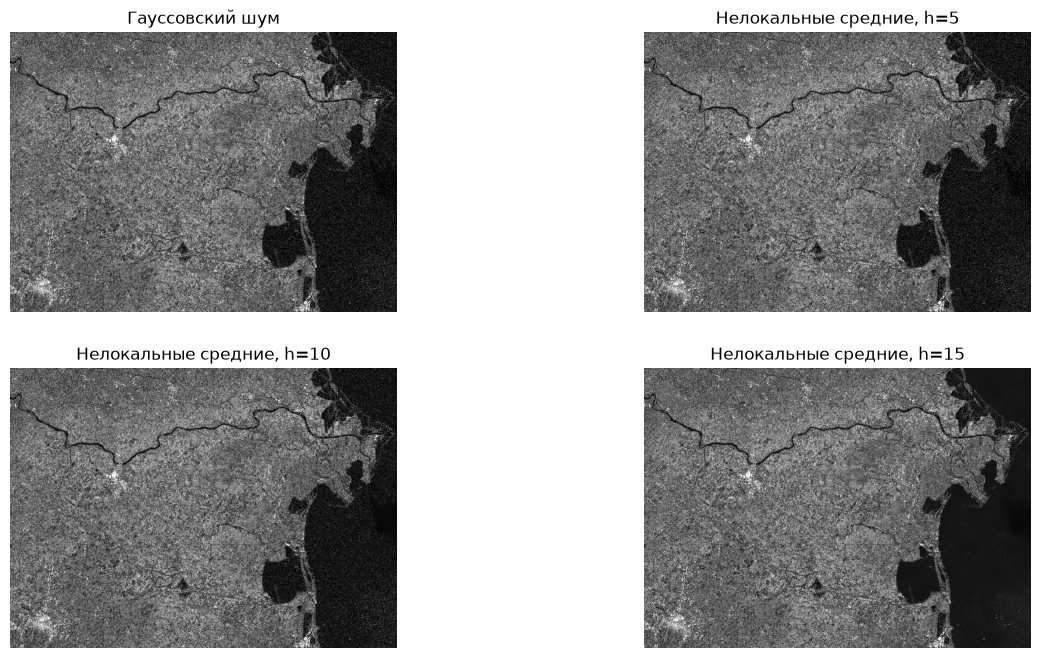

In [16]:
nlm_1 = cv2.fastNlMeansDenoising(gaussian_image, None, 5, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(gaussian_image, None, 10, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(gaussian_image, None, 15, 7, 21)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(nlm_1, cmap='gray')
plt.title('Нелокальные средние, h=5')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(nlm_2, cmap='gray')
plt.title('Нелокальные средние, h=10')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(nlm_3, cmap='gray')
plt.title('Нелокальные средние, h=15')
plt.axis('off')

plt.show()

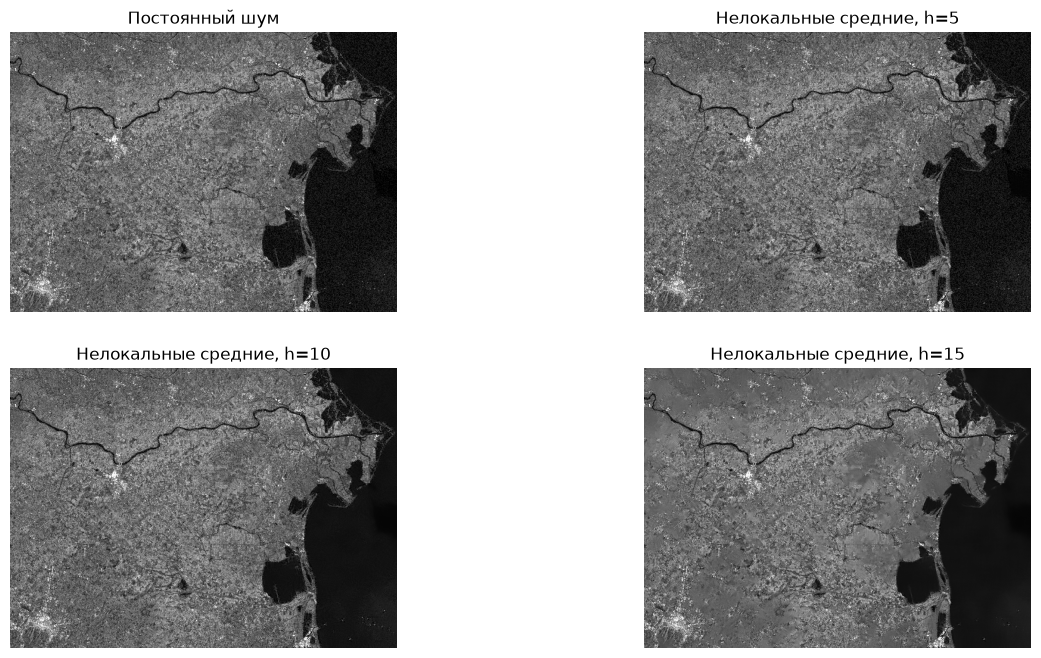

In [32]:
uniform_nlm_1 = cv2.fastNlMeansDenoising(uniform_image, None, 5, 7, 21)
uniform_nlm_2 = cv2.fastNlMeansDenoising(uniform_image, None, 10, 7, 21)
uniform_nlm_3 = cv2.fastNlMeansDenoising(uniform_image, None, 15, 7, 21)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(uniform_nlm_1, cmap='gray')
plt.title('Нелокальные средние, h=5')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(uniform_nlm_2, cmap='gray')
plt.title('Нелокальные средние, h=10')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(uniform_nlm_3, cmap='gray')
plt.title('Нелокальные средние, h=15')
plt.axis('off')

plt.show()

In [23]:
results_gaussian = {
    'Без фильтра': gaussian_image,
    'Медианный 3x3': median_3,
    'Медианный 5x5': median_5,
    'Медианный 7x7': median_7,
    'Гаусса 3x3': gauss_3,
    'Гаусса 5x5': gauss_5,
    'Гаусса 7x7': gauss_7,
    'Билатеральный (5,25,25)': bilateral_1,
    'Билатеральный (9,50,50)': bilateral_2,
    'Билатеральный (15,75,75)': bilateral_3,
    'Нелокальные средние, h=5': nlm_1,
    'Нелокальные средние, h=10': nlm_2,
    'Нелокальные средние, h=15': nlm_3
}

print('Сравнение фильтров для гауссовского шума:\n')

for name, img in results_gaussian.items():
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)

    print(name)
    print('MSE:', round(mse, 2))
    print('SSIM:', round(ssim, 4))
    print()

Сравнение фильтров для гауссовского шума:

Без фильтра
MSE: 579.11
SSIM: 0.5996

Медианный 3x3
MSE: 543.07
SSIM: 0.4398

Медианный 5x5
MSE: 583.61
SSIM: 0.3558

Медианный 7x7
MSE: 630.97
SSIM: 0.298

Гаусса 3x3
MSE: 377.91
SSIM: 0.5915

Гаусса 5x5
MSE: 437.11
SSIM: 0.519

Гаусса 7x7
MSE: 497.55
SSIM: 0.4429

Билатеральный (5,25,25)
MSE: 351.72
SSIM: 0.6742

Билатеральный (9,50,50)
MSE: 293.87
SSIM: 0.6602

Билатеральный (15,75,75)
MSE: 433.64
SSIM: 0.5037

Нелокальные средние, h=5
MSE: 579.11
SSIM: 0.5996

Нелокальные средние, h=10
MSE: 562.83
SSIM: 0.6083

Нелокальные средние, h=15
MSE: 491.29
SSIM: 0.6977



In [33]:
results_uniform = {
    'Без фильтра': uniform_image,
    'Медианный 3x3': uniform_median_3,
    'Медианный 5x5': uniform_median_5,
    'Медианный 7x7': uniform_median_7,
    'Гаусса 3x3': uniform_gauss_3,
    'Гаусса 5x5': uniform_gauss_5,
    'Гаусса 7x7': uniform_gauss_7,
    'Билатеральный (5,25,25)': uniform_bilateral_1,
    'Билатеральный (9,50,50)': uniform_bilateral_2,
    'Билатеральный (15,75,75)': uniform_bilateral_3,
    'Нелокальные средние, h=5': uniform_nlm_1,
    'Нелокальные средние, h=10': uniform_nlm_2,
    'Нелокальные средние, h=15': uniform_nlm_3
}

print('Сравнение фильтров для постоянного шума:\n')

for name, img in results_uniform.items():
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)

    print(name)
    print('MSE:', round(mse, 2))
    print('SSIM:', round(ssim, 4))
    print()

Сравнение фильтров для постоянного шума:

Без фильтра
MSE: 202.81
SSIM: 0.7697

Медианный 3x3
MSE: 476.72
SSIM: 0.4872

Медианный 5x5
MSE: 557.57
SSIM: 0.3777

Медианный 7x7
MSE: 618.72
SSIM: 0.3085

Гаусса 3x3
MSE: 321.27
SSIM: 0.6497

Гаусса 5x5
MSE: 405.18
SSIM: 0.5527

Гаусса 7x7
MSE: 478.6
SSIM: 0.4613

Билатеральный (5,25,25)
MSE: 137.21
SSIM: 0.8276

Билатеральный (9,50,50)
MSE: 276.65
SSIM: 0.6499

Билатеральный (15,75,75)
MSE: 456.26
SSIM: 0.4578

Нелокальные средние, h=5
MSE: 202.54
SSIM: 0.7701

Нелокальные средние, h=10
MSE: 174.28
SSIM: 0.8501

Нелокальные средние, h=15
MSE: 151.31
SSIM: 0.8268



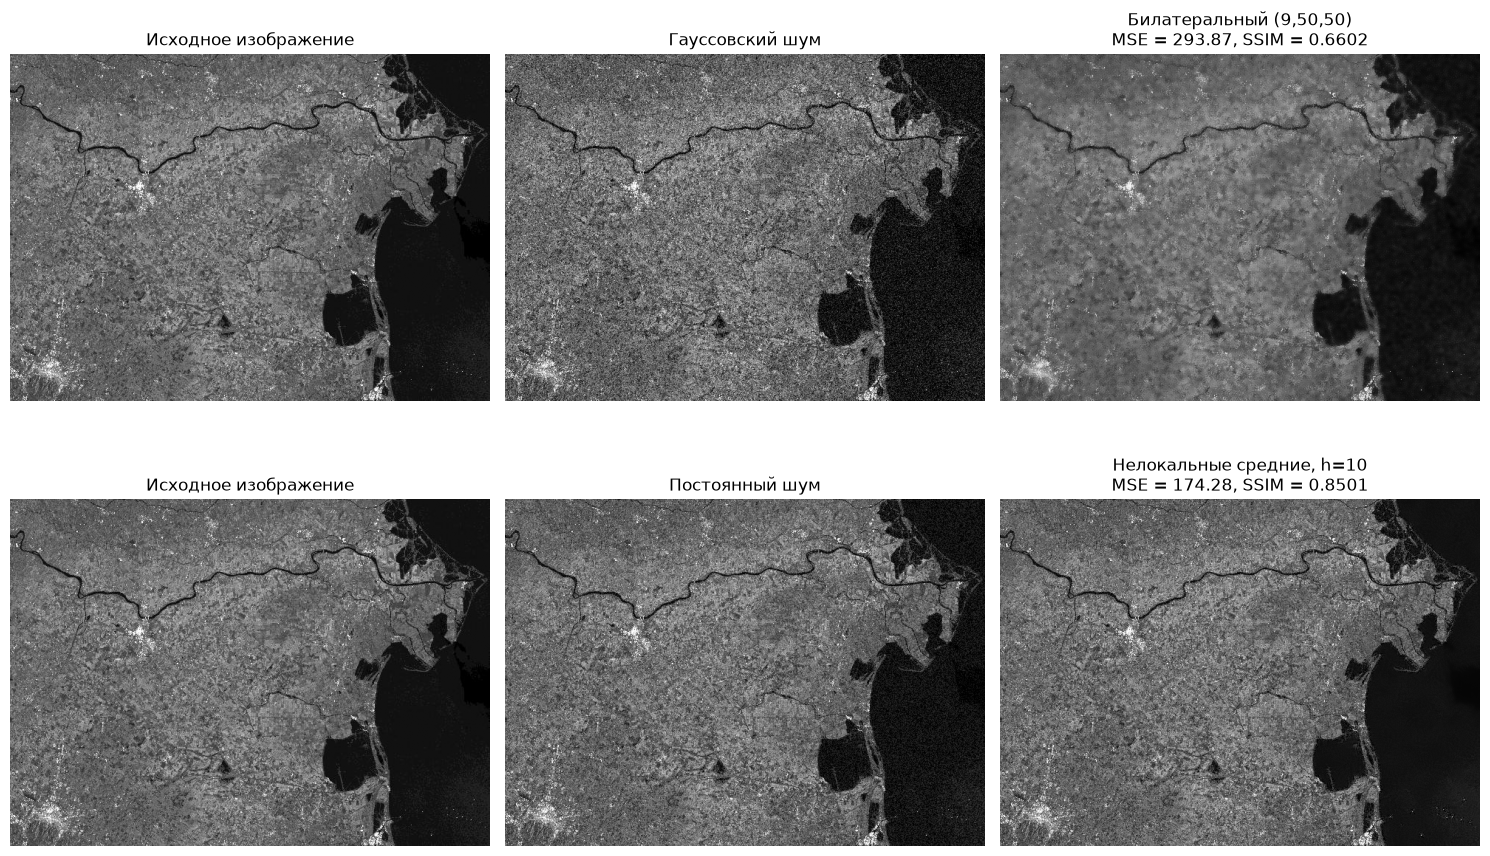


Вывод:

В ходе работы были протестированы медианный фильтр, фильтр Гаусса, билатеральный фильтр и фильтр нелокальных средних с различными параметрами. Для гауссовского шума лучший результат по значению MSE показал Билатеральный (9,50,50) — MSE = 293.87, SSIM = 0.6602. Для постоянного шума лучший результат показал Нелокальные средние, h=10 — MSE = 174.28, SSIM = 0.8501. Таким образом, эффективность фильтрации зависит от типа шума и выбранных параметров фильтра.


In [43]:
gaussian_filters = {
    name: img
    for name, img in results_gaussian.items()
    if name != 'Без фильтра'
}

best_gaussian_name = min(
    gaussian_filters,
    key=lambda name: mean_squared_error(
        image_gray,
        gaussian_filters[name]
    )
)

best_gaussian_image = gaussian_filters[best_gaussian_name]

best_gaussian_mse = mean_squared_error(
    image_gray,
    best_gaussian_image
)

best_gaussian_ssim = structural_similarity(
    image_gray,
    best_gaussian_image
)

best_uniform_name = 'Нелокальные средние, h=10'
best_uniform_image = results_uniform[best_uniform_name]

best_uniform_mse = mean_squared_error(
    image_gray,
    best_uniform_image
)

best_uniform_ssim = structural_similarity(
    image_gray,
    best_uniform_image
)

plt.figure(figsize=(15, 9))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(best_gaussian_image, cmap='gray')
plt.title(
    f'{best_gaussian_name}\n'
    f'MSE = {best_gaussian_mse:.2f}, SSIM = {best_gaussian_ssim:.4f}'
)
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(best_uniform_image, cmap='gray')
plt.title(
    f'{best_uniform_name}\n'
    f'MSE = {best_uniform_mse:.2f}, SSIM = {best_uniform_ssim:.4f}'
)
plt.axis('off')

plt.tight_layout(h_pad=4)
plt.show()

print()
print('Вывод:')
print()
print(
    f'В ходе работы были протестированы медианный фильтр, фильтр Гаусса, '
    f'билатеральный фильтр и фильтр нелокальных средних с различными параметрами. '
    f'Для гауссовского шума лучший результат по значению MSE показал '
    f'{best_gaussian_name} — MSE = {best_gaussian_mse:.2f}, '
    f'SSIM = {best_gaussian_ssim:.4f}. '
    f'Для постоянного шума лучший результат показал '
    f'{best_uniform_name} — MSE = {best_uniform_mse:.2f}, '
    f'SSIM = {best_uniform_ssim:.4f}. '
    f'Таким образом, эффективность фильтрации зависит от типа шума '
    f'и выбранных параметров фильтра.'
)